# 02 · Predicting Profit and Loss-Making Sales

Two questions, both answered **without target leakage**:

1. **Regression:** how well can the `Profit` of an order line be predicted from information known at sale time?
2. **Classification:** can we flag lines that will lose money (`Profit < 0`)?

Section 2 reproduces the first version of this project, shows that its R² came from leaked features, and explains the fix.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (r2_score, mean_absolute_error, median_absolute_error,
                             mean_squared_error, roc_auc_score, f1_score,
                             classification_report, ConfusionMatrixDisplay)
from xgboost import XGBRegressor, XGBClassifier

sns.set_theme(style="whitegrid")
ASSETS = Path("../assets"); ASSETS.mkdir(exist_ok=True)
SEED = 42

df = pd.read_csv("../data/superstore.csv", encoding="latin1")
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Year"]  = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Sales_log"] = np.log1p(df["Sales"])
df["Discount_Sales"] = df["Discount"] * df["Sales"]
y = df["Profit"]
print(df.shape)

(9994, 25)


## 1. Why Profit is hard to model

Profit is extremely heavy-tailed: the median is about $9 but single lines reach +$8,400 and -$6,600. 
A few lines dominate squared-error metrics, so a single train/test split can give very different R² depending on where those lines land. 
For that reason every comparison below uses **5-fold cross-validation**, and MAE is reported next to R².

In [2]:
print(y.describe().round(2))
print("Lines with |profit| > $2,000:", int((y.abs() > 2000).sum()))

count    9994.00
mean       28.66
std       234.26
min     -6599.98
25%         1.73
50%         8.67
75%        29.36
max      8399.98
Name: Profit, dtype: float64
Lines with |profit| > $2,000: 22


## 2. The original setup and the leakage problem

In [3]:
# Features of the first version of this project
orig = df.copy()
orig["Profit Ratio"]     = orig["Profit"] / orig["Sales"]       # built from the target
orig["Profit_per_Unit"]  = orig["Profit"] / orig["Quantity"]    # built from the target
orig = pd.get_dummies(orig, columns=["Category", "Segment", "Region"], drop_first=True)

drop_always = ["Profit", "Order Date", "Ship Date"]
leaky = ["Profit Ratio", "Profit_per_Unit"]
ids   = ["Row ID", "Postal Code"]          # identifiers, not real numeric features

def holdout_r2(X, y, model):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=SEED)
    return model.fit(Xtr, ytr).score(Xte, yte)

def numeric(frame, drop): return frame.drop(columns=drop, errors="ignore").select_dtypes("number")

models_small = {
    "Linear":  LinearRegression(),
    "Lasso":   Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(random_state=SEED, n_jobs=-1),
    "XGBoost": XGBRegressor(random_state=SEED),
}
rows = []
for name, m in models_small.items():
    rows.append({
        "model": name,
        "original (leaky)":      holdout_r2(numeric(orig, drop_always), y, m),
        "no leaky columns":      holdout_r2(numeric(orig, drop_always + leaky), y, m),
        "no leaky, no IDs":      holdout_r2(numeric(orig, drop_always + leaky + ids), y, m),
    })
leak_table = pd.DataFrame(rows).set_index("model")
leak_table.round(3)

,original (leaky),no leaky columns,"no leaky, no IDs"
model,,,
Linear,0.787,0.419,0.419
Lasso,0.789,0.417,0.417
Random Forest,0.624,-0.111,-0.119
XGBoost,0.616,0.063,-0.072


Removing `Profit Ratio` and `Profit_per_Unit` (both computed from `Profit`) makes the linear models fall from about 0.79 to about 0.42, while Random Forest and XGBoost collapse to roughly -0.1 and 0.06. 
`Row ID` and `Postal Code` are identifiers, so they are dropped as well. The earlier conclusion "Lasso is the best model" was an artifact of leakage. 
(Random Forest and XGBoost values differ slightly from the first README because those models depend on random seeds and library versions; the linear results are identical.)

With only these few numeric features the models still miss one important piece of information: **what product was sold**. The next section adds it.

## 3. Leak-free feature set

In [4]:
numeric_features = ["Sales", "Quantity", "Discount", "Sales_log", "Discount_Sales", "Month", "Year"]
categorical_features = ["Sub-Category", "Segment", "Region", "Ship Mode"]   # Sub-Category already contains Category

X = pd.get_dummies(df[numeric_features + categorical_features],
                   columns=categorical_features, drop_first=True)
print("Features:", X.shape[1])
print("Excluded on purpose: Profit Ratio, Profit_per_Unit (target leakage), Row ID, Postal Code (identifiers), customer / product names")

Features: 31
Excluded on purpose: Profit Ratio, Profit_per_Unit (target leakage), Row ID, Postal Code (identifiers), customer / product names


## 4. Regression (5-fold cross-validation)

In [5]:
reg_models = {
    "Linear":        make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge":         make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Lasso":         make_pipeline(StandardScaler(), Lasso(alpha=0.1)),
    "Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=SEED, n_jobs=-1),
    "XGBoost":       XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=SEED),
}
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {"r2": "r2", "mae": "neg_mean_absolute_error", "mse": "neg_mean_squared_error"}

rows, fold_r2 = [], {}
for name, m in reg_models.items():
    r = cross_validate(m, X, y, cv=kf, scoring=scoring, n_jobs=1)
    fold_r2[name] = r["test_r2"]
    rows.append({"model": name,
                 "R2 mean": r["test_r2"].mean(), "R2 std": r["test_r2"].std(),
                 "R2 min fold": r["test_r2"].min(), "R2 max fold": r["test_r2"].max(),
                 "MAE ($)": -r["test_mae"].mean(),
                 "RMSE ($)": np.sqrt(-r["test_mse"]).mean()})
cv_table = pd.DataFrame(rows).set_index("model").sort_values("MAE ($)")
cv_table.round(3)

,R2 mean,R2 std,R2 min fold,R2 max fold,MAE ($),RMSE ($)
model,,,,,,
XGBoost,0.842,0.069,0.737,0.920,19.996,92.072
Random Forest,0.663,0.241,0.217,0.894,22.760,128.880
Lasso,0.715,0.161,0.399,0.841,40.525,117.633
Ridge,0.715,0.160,0.399,0.840,40.750,117.652
Linear,0.715,0.161,0.399,0.840,40.762,117.655


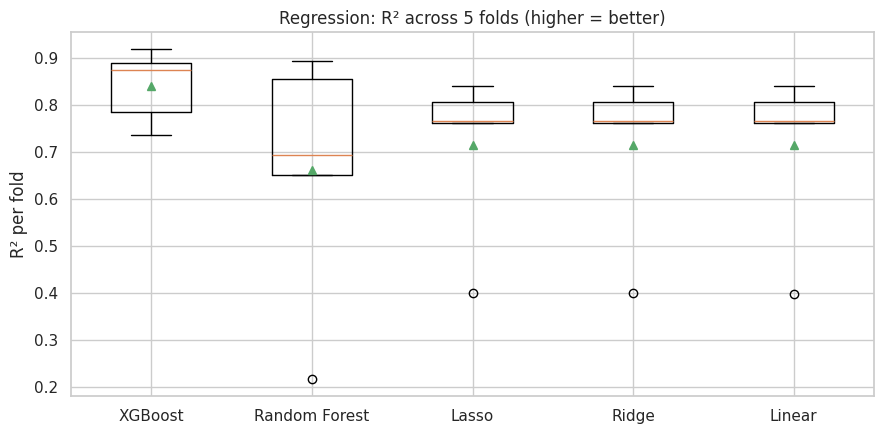

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = cv_table.index
ax.boxplot([fold_r2[m] for m in order], labels=order, showmeans=True)
ax.set_ylabel("R² per fold"); ax.set_title("Regression: R² across 5 folds (higher = better)")
plt.tight_layout()
plt.savefig(ASSETS / "05_regression_cv.png", dpi=130, bbox_inches="tight"); plt.show()

R² varies strongly from fold to fold because of the extreme lines, so the **MAE column is the more stable measure**. 
Tree-based boosting (XGBoost) is clearly better on MAE, which makes sense: profit is roughly `sales × margin`, and the margin depends on sub-category and discount in a non-linear, interacting way that linear models cannot capture.

### Hold-out check of the best model

In [7]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=SEED)
best = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=SEED).fit(Xtr, ytr)
pred = best.predict(Xte)

print(f"R²              : {r2_score(yte, pred):.3f}")
print(f"MAE             : ${mean_absolute_error(yte, pred):.2f}")
print(f"Median abs error: ${median_absolute_error(yte, pred):.2f}")
print(f"RMSE            : ${np.sqrt(mean_squared_error(yte, pred)):.2f}")

R²              : 0.843
MAE             : $20.20
Median abs error: $4.73
RMSE            : $87.21


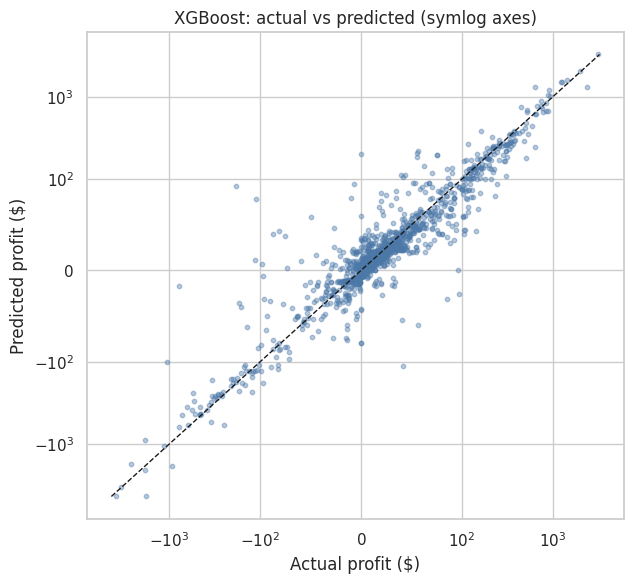

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(yte, pred, s=10, alpha=0.4, color="#4C78A8")
lim = [min(yte.min(), pred.min()), max(yte.max(), pred.max())]
ax.plot(lim, lim, "k--", lw=1)
ax.set_xscale("symlog", linthresh=100); ax.set_yscale("symlog", linthresh=100)
ax.set_xlabel("Actual profit ($)"); ax.set_ylabel("Predicted profit ($)")
ax.set_title("XGBoost: actual vs predicted (symlog axes)")
plt.tight_layout()
plt.savefig(ASSETS / "06_actual_vs_predicted.png", dpi=130, bbox_inches="tight"); plt.show()

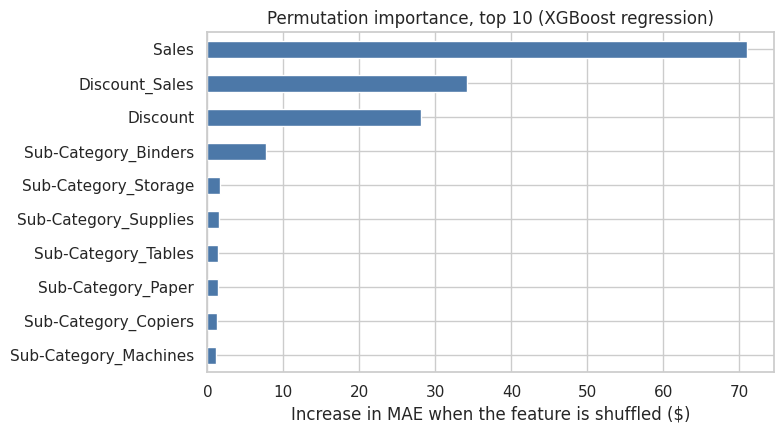

Sales                    71.01
Discount_Sales           34.11
Discount                 28.10
Sub-Category_Binders      7.68
Sub-Category_Storage      1.68
Sub-Category_Supplies     1.57
Sub-Category_Tables       1.36
Sub-Category_Paper        1.34
Sub-Category_Copiers      1.31
Sub-Category_Machines     1.08
dtype: float64

In [9]:
imp = permutation_importance(best, Xte, yte, n_repeats=5, random_state=SEED,
                             scoring="neg_mean_absolute_error", n_jobs=-1)
imp_s = pd.Series(imp.importances_mean, index=X.columns).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 4.5))
imp_s[::-1].plot(kind="barh", ax=ax, color="#4C78A8")
ax.set_xlabel("Increase in MAE when the feature is shuffled ($)")
ax.set_title("Permutation importance, top 10 (XGBoost regression)")
plt.tight_layout()
plt.savefig(ASSETS / "07_feature_importance.png", dpi=130, bbox_inches="tight"); plt.show()
imp_s.round(2)

## 5. Classification: which lines lose money?

In [10]:
yc = (y < 0).astype(int)
print(f"Loss-making lines: {yc.mean():.1%}")

clf_models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=3, class_weight="balanced",
                                            random_state=SEED, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=SEED),
}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
rows = []
for name, m in clf_models.items():
    r = cross_validate(m, X, yc, cv=skf, scoring={"auc": "roc_auc", "f1": "f1"})
    rows.append({"model": name, "AUC mean": r["test_auc"].mean(), "AUC std": r["test_auc"].std(),
                 "F1 mean": r["test_f1"].mean(), "F1 std": r["test_f1"].std()})
clf_table = pd.DataFrame(rows).set_index("model")
clf_table.round(3)

Loss-making lines: 18.7%


,AUC mean,AUC std,F1 mean,F1 std
model,,,,
Logistic Regression,0.985,0.001,0.844,0.011
Random Forest,0.986,0.001,0.849,0.008
XGBoost,0.986,0.002,0.850,0.014


Hold-out AUC: 0.986

              precision    recall  f1-score   support

      profit      0.952     0.986     0.969      1625
        loss      0.930     0.783     0.851       374

    accuracy                          0.948      1999
   macro avg      0.941     0.885     0.910      1999
weighted avg      0.948     0.948     0.947      1999



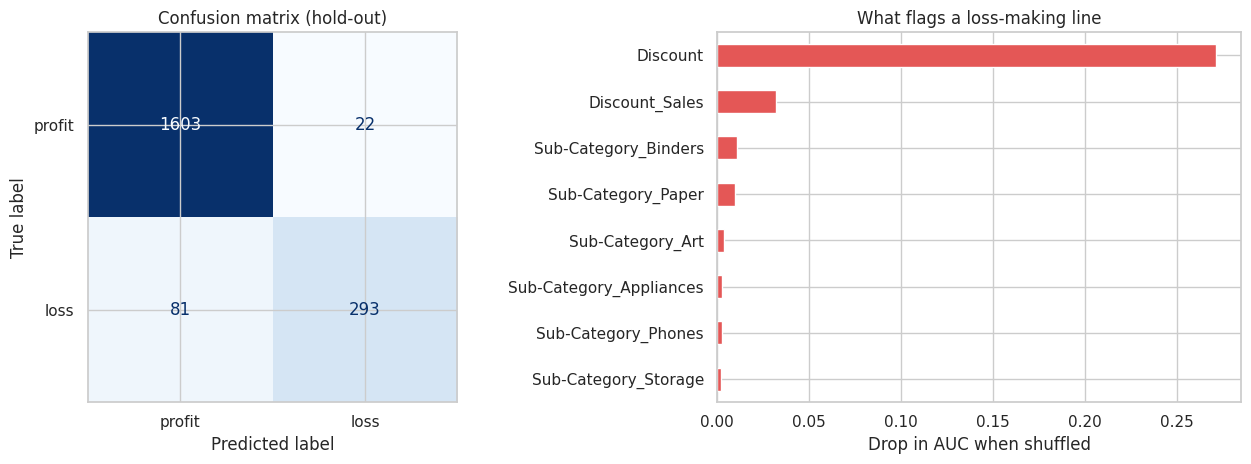

Discount                   0.272
Discount_Sales             0.032
Sub-Category_Binders       0.011
Sub-Category_Paper         0.010
Sub-Category_Art           0.004
Sub-Category_Appliances    0.003
Sub-Category_Phones        0.003
Sub-Category_Storage       0.002
dtype: float64

In [11]:
Xtr, Xte, ytr, yte = train_test_split(X, yc, test_size=0.2, random_state=SEED, stratify=yc)
clf = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=SEED).fit(Xtr, ytr)
proba = clf.predict_proba(Xte)[:, 1]
print(f"Hold-out AUC: {roc_auc_score(yte, proba):.3f}\n")
print(classification_report(yte, (proba > 0.5).astype(int), target_names=["profit", "loss"], digits=3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ConfusionMatrixDisplay.from_predictions(yte, (proba > 0.5).astype(int),
    display_labels=["profit", "loss"], cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix (hold-out)")

imp = permutation_importance(clf, Xte, yte, n_repeats=5, random_state=SEED, scoring="roc_auc", n_jobs=-1)
s = pd.Series(imp.importances_mean, index=X.columns).sort_values(ascending=False).head(8)
s[::-1].plot(kind="barh", ax=axes[1], color="#E45756")
axes[1].set_xlabel("Drop in AUC when shuffled"); axes[1].set_title("What flags a loss-making line")
plt.tight_layout()
plt.savefig(ASSETS / "08_loss_classifier.png", dpi=130, bbox_inches="tight"); plt.show()
s.round(3)

### Does the model beat a simple rule?

In [12]:
rule_pred = (df.loc[yte.index, "Discount"] > 0.20).astype(int)
print("Rule: 'discount > 20%' -> loss")
print(f"  precision {((rule_pred == 1) & (yte == 1)).sum() / rule_pred.sum():.3f}   "
      f"recall {((rule_pred == 1) & (yte == 1)).sum() / yte.sum():.3f}   F1 {f1_score(yte, rule_pred):.3f}")
model_pred = (proba > 0.5).astype(int)
print("XGBoost classifier")
print(f"  precision {((model_pred == 1) & (yte == 1)).sum() / model_pred.sum():.3f}   "
      f"recall {((model_pred == 1) & (yte == 1)).sum() / yte.sum():.3f}   F1 {f1_score(yte, model_pred):.3f}")

Rule: 'discount > 20%' -> loss
  precision 0.964   recall 0.722   F1 0.826
XGBoost classifier
  precision 0.930   recall 0.783   F1 0.851


The one-line discount rule is already very strong, and the model adds only a small improvement (mostly recall, from also using product type and order size). 
This is useful business information: **the loss problem can be controlled with a discount policy, without a complex model.** The classifier's main value is catching the remaining loss lines that sit below the 20% threshold.

## 6. Summary

**Leakage fix**
- The first version used `Profit Ratio` and `Profit_per_Unit` (derived from `Profit`) as inputs, plus ID columns. Removing them drops linear R² from 0.79 to 0.42 on the same features: the old "Lasso is best" result was not real.

**Regression (5-fold CV, leak-free features incl. sub-category)**
- XGBoost: R² 0.84 (±0.07), MAE about $20. Hold-out: R² 0.84, MAE $20.20, median absolute error $4.73.
- Linear / Ridge / Lasso: R² 0.72 but MAE about $41, i.e. twice the error of XGBoost. Random Forest: R² 0.66 with large fold-to-fold variation.
- Profit is dominated by a handful of extreme lines (22 lines beyond ±$2,000), so R² is unstable; MAE and cross-validation give a fairer picture.
- Most important inputs: `Sales`, `Discount_Sales`, `Discount`, then sub-category (Binders).

**Loss classification**
- Cross-validated AUC about 0.986 for all three models, F1 about 0.85; even logistic regression performs as well.
- `Discount` is by far the most important feature. The rule "discount > 20%" alone reaches a similar F1, so a discount cap is the practical action.

**Limits**
- Random 80/20 and K-fold splits mix years; a time-based split would be the stricter test for forecasting use.
- Predictions use `Sales` and `Discount` of the same line, which are known when the sale is priced but not before.